# Random Forest - Learning Tool
This notebook builds intuition for how **Random Forests** work by manually demonstrating the three sampling strategies used internally.

## Step 1: Generate Dataset

In [53]:
import numpy as np
import pandas as pd
import random
from sklearn.datasets import make_classification

In [54]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

In [55]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,-0.464706,-0.834929,-1.064801,2.202519,1.202843,0
1,-0.859335,-1.496835,1.774470,-0.694233,-0.592162,1
2,-2.228353,-1.412218,1.836870,-2.735804,-1.451948,1
3,-0.158966,-1.085153,1.222517,0.993020,0.477164,0
4,-1.328921,-0.776364,0.573043,-0.368075,-0.664961,1


## Step 2: Sampling Helper Functions
Three functions power the Random Forest mechanism:

### `sample_rows` — Row Sampling (Bootstrapping)
Samples rows **with replacement**. Each tree sees a different subset of training examples.

In [56]:
# function for row sampling

def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)

### `sample_features` — Feature Sampling (Random Subspaces)
Samples a random subset of **columns** (features). Reduces correlation between trees.

In [57]:
# function for feature sampling
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df

### `combined_sampling` — Random Patches
Combines row + feature sampling. Each tree sees a different patch of the data — this is the core of Random Forest.

In [58]:
# function for combined sampling

def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

---
## Demo 1: Row Sampling Only
Create 3 datasets by sampling 50% of rows with replacement. Each dataset is different, so each tree learns slightly different patterns.

In [59]:
dr1 = sample_rows(df, 0.5)
dr2 = sample_rows(df, 0.5)
dr3 = sample_rows(df, 0.5)

print('dr1 shape:', dr1.shape)
print('dr2 shape:', dr2.shape)
print('dr3 shape:', dr3.shape)

dr1 shape: (50, 6)
dr2 shape: (50, 6)
dr3 shape: (50, 6)


In [60]:
dr1

,col1,col2,col3,col4,col5,target
97,-1.607563,-0.146120,-1.525887,-0.820414,-1.376918,1
77,0.313822,3.166155,-1.068393,1.464147,-3.592263,0
80,0.933446,-1.366462,0.480187,0.801684,-0.489309,0
89,-1.460865,0.975247,-0.012151,1.882153,0.832635,0
47,-0.988398,1.993318,1.201231,0.678481,1.149409,0
78,-1.403792,2.728173,-0.367984,2.250320,-0.809870,0
63,-0.581309,0.930616,0.553395,1.196602,0.534210,0
76,-2.149425,0.583012,-2.047995,3.833969,1.205534,0
80,0.933446,-1.366462,0.480187,0.801684,-0.489309,0
17,-0.936037,1.376543,1.336502,0.940335,1.455594,0


### Train 3 Trees on Row-Sampled Data

In [61]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

rclf1 = DecisionTreeClassifier(max_depth=3)
rclf2 = DecisionTreeClassifier(max_depth=3)
rclf3 = DecisionTreeClassifier(max_depth=3)

rclf1.fit(dr1.iloc[:,0:2], dr1.iloc[:,-1])
rclf2.fit(dr2.iloc[:,0:2], dr2.iloc[:,-1])
rclf3.fit(dr3.iloc[:,0:2], dr3.iloc[:,-1])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

### Tree Visualizations (Row Sampling)

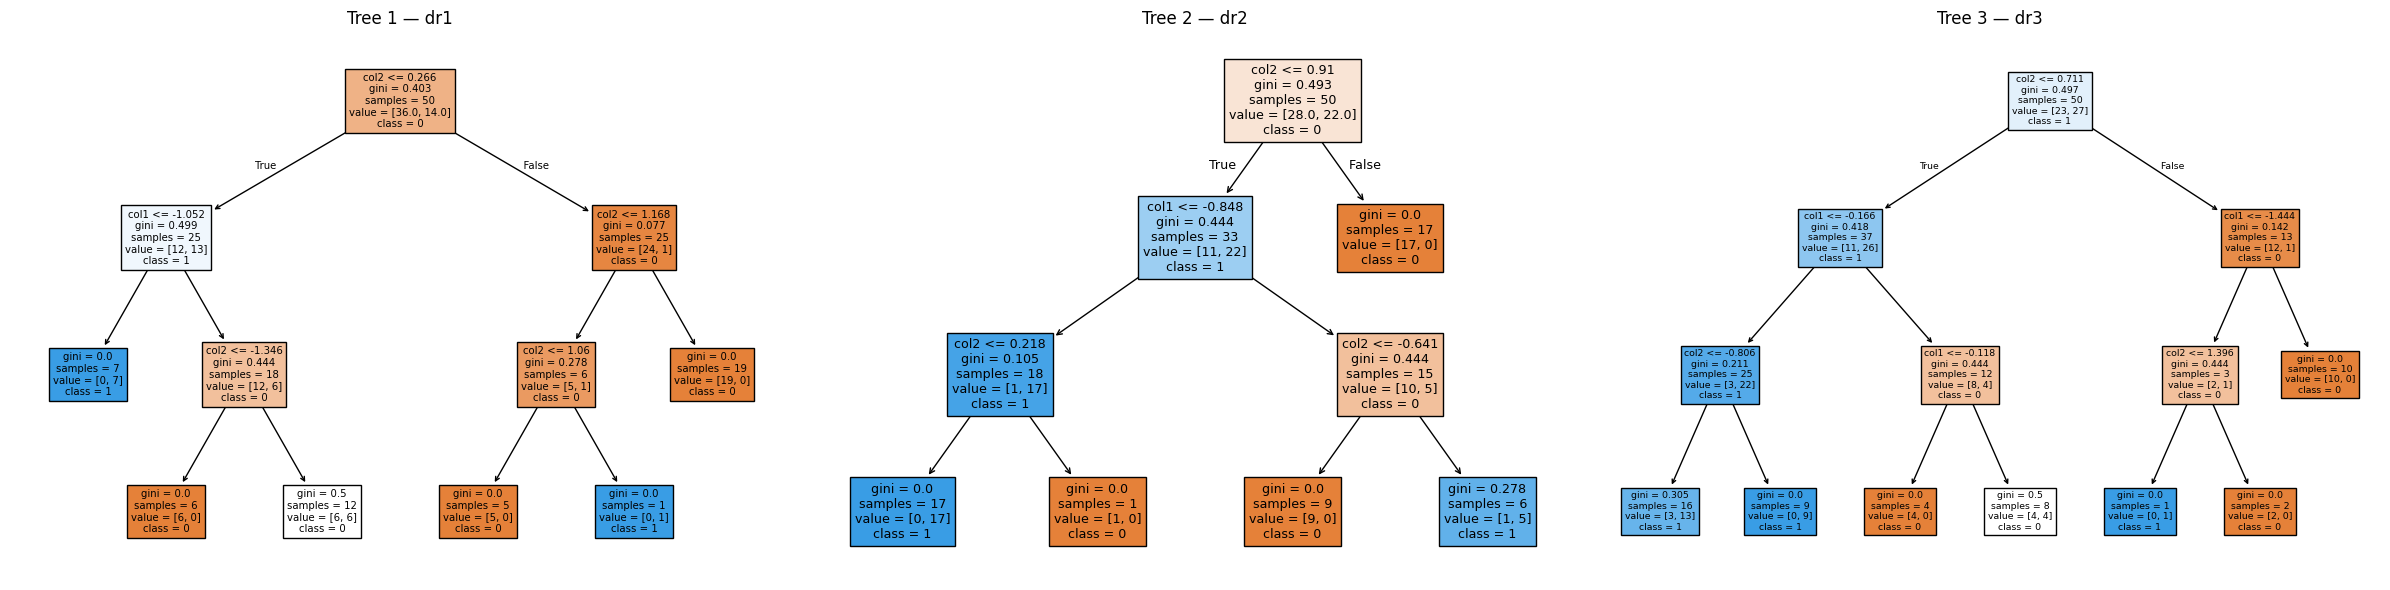

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(24, 6))
plot_tree(rclf1, feature_names=['col1','col2'], class_names=['0','1'], filled=True, ax=axes[0])
axes[0].set_title('Tree 1 — dr1')
plot_tree(rclf2, feature_names=['col1','col2'], class_names=['0','1'], filled=True, ax=axes[1])
axes[1].set_title('Tree 2 — dr2')
plot_tree(rclf3, feature_names=['col1','col2'], class_names=['0','1'], filled=True, ax=axes[2])
axes[2].set_title('Tree 3 — dr3')
plt.tight_layout()
plt.show()

### Predictions from Each Tree (Row Sampling)
Same input, different trees → may give different votes. Final prediction = majority vote.

In [63]:
test_point = np.array([-1.042498, -0.064323]).reshape(1,2)
p1 = rclf1.predict(test_point)[0]
p2 = rclf2.predict(test_point)[0]
p3 = rclf3.predict(test_point)[0]
print(f'Tree 1 predicts: {p1}')
print(f'Tree 2 predicts: {p2}')
print(f'Tree 3 predicts: {p3}')
print(f'Majority vote  : {max([p1,p2,p3], key=[p1,p2,p3].count)}')

Tree 1 predicts: 0
Tree 2 predicts: 1
Tree 3 predicts: 1
Majority vote  : 1


d:\PENDRIVE 32 GB\Game\AI_PROJECTS\Machine Learning\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
d:\PENDRIVE 32 GB\Game\AI_PROJECTS\Machine Learning\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
d:\PENDRIVE 32 GB\Game\AI_PROJECTS\Machine Learning\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


---
## Demo 2: Combined Sampling (Random Patches)
Each tree sees 50% of rows **and** 50% of features — notice the columns differ between trees.

In [64]:
df1 = combined_sampling(df, 0.5, 0.5)
df2 = combined_sampling(df, 0.5, 0.5)
df3 = combined_sampling(df, 0.5, 0.5)

print('df1 columns:', df1.columns.tolist())
print('df2 columns:', df2.columns.tolist())
print('df3 columns:', df3.columns.tolist())

df1 columns: ['col3', 'col4', 'target']
df2 columns: ['col2', 'col1', 'target']
df3 columns: ['col4', 'col5', 'target']


In [65]:
df1

,col3,col4,target
64,2.019975,0.109846,0
0,-1.064801,2.202519,0
52,2.845504,-0.726407,0
7,-0.757103,-0.588764,1
46,-1.550147,2.859980,0
39,-0.618320,2.320939,0
32,-0.819920,-0.348361,1
8,2.262854,-3.018497,1
60,1.268140,0.509059,0
41,-0.071816,0.164184,1


### Train 3 Trees on Combined-Sampled Data

In [66]:
clf1 = DecisionTreeClassifier(max_depth=3)
clf2 = DecisionTreeClassifier(max_depth=3)
clf3 = DecisionTreeClassifier(max_depth=3)

clf1.fit(df1.iloc[:,0:2], df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2], df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2], df3.iloc[:,-1])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

### Tree Visualizations (Combined Sampling)

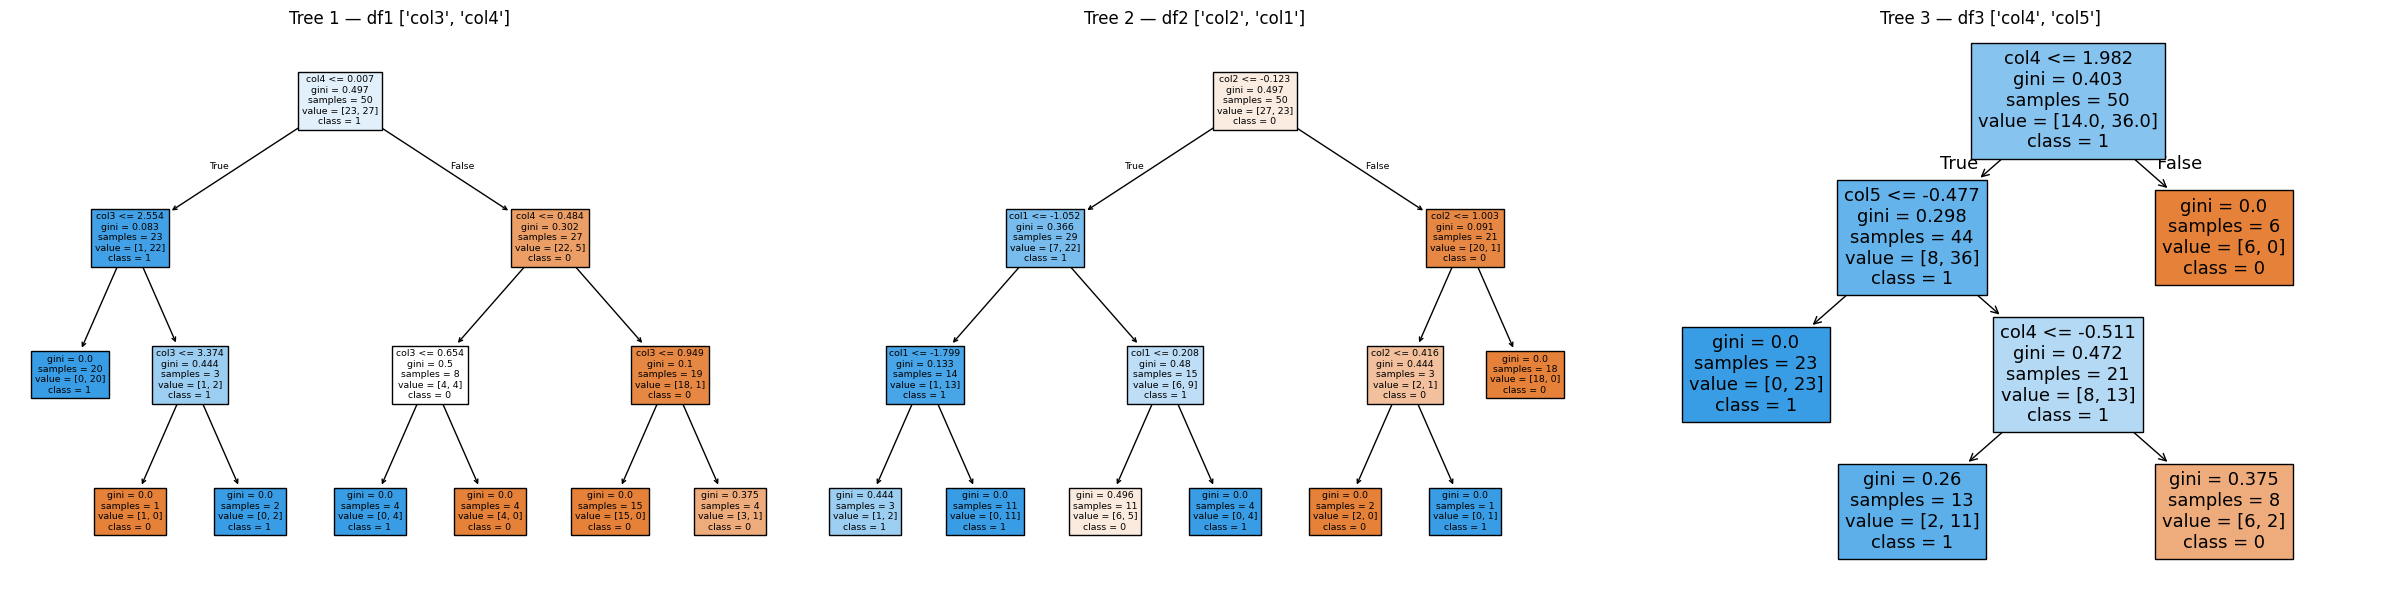

In [67]:
fig, axes = plt.subplots(1, 3, figsize=(24, 6))
plot_tree(clf1, feature_names=df1.columns[:-1].tolist(), class_names=['0','1'], filled=True, ax=axes[0])
axes[0].set_title('Tree 1 — df1 ' + str(df1.columns[:-1].tolist()))
plot_tree(clf2, feature_names=df2.columns[:-1].tolist(), class_names=['0','1'], filled=True, ax=axes[1])
axes[1].set_title('Tree 2 — df2 ' + str(df2.columns[:-1].tolist()))
plot_tree(clf3, feature_names=df3.columns[:-1].tolist(), class_names=['0','1'], filled=True, ax=axes[2])
axes[2].set_title('Tree 3 — df3 ' + str(df3.columns[:-1].tolist()))
plt.tight_layout()
plt.show()

### Predictions from Each Tree (Combined Sampling)

In [68]:
feat1 = df1.columns[:-1].tolist()
feat2 = df2.columns[:-1].tolist()
feat3 = df3.columns[:-1].tolist()

# Build a full-feature test point as a dict, then select each tree's features
import pandas as pd
full_cols = ['col1','col2','col3','col4','col5']
test_vals = [-1.042498, -0.064323, 0.0, 0.0, 0.0]  # remaining cols zeroed
test_df = pd.DataFrame([test_vals], columns=full_cols)

p1 = clf1.predict(test_df[feat1])[0]
p2 = clf2.predict(test_df[feat2])[0]
p3 = clf3.predict(test_df[feat3])[0]
print(f'Tree 1 (features {feat1}) predicts: {p1}')
print(f'Tree 2 (features {feat2}) predicts: {p2}')
print(f'Tree 3 (features {feat3}) predicts: {p3}')
print(f'Majority vote: {max([p1,p2,p3], key=[p1,p2,p3].count)}')

Tree 1 (features ['col3', 'col4']) predicts: 1
Tree 2 (features ['col2', 'col1']) predicts: 0
Tree 3 (features ['col4', 'col5']) predicts: 0
Majority vote: 0


---
## Bonus: Bootstrap Sample Example
This shows how `sample(..., replace=True)` can return duplicate rows — the foundation of bagging.

In [69]:
df.sample(14, replace=True)

,col1,col2,col3,col4,col5,target
46,-0.374147,-2.365490,-1.550147,2.859980,-0.184382,0
39,-1.210343,1.499272,-0.618320,2.320939,-1.050087,0
42,-0.130613,-0.099367,2.912746,-0.935771,2.703520,0
79,-0.236615,4.850302,2.650669,-1.240388,-0.705788,0
76,-2.149425,0.583012,-2.047995,3.833969,1.205534,0
89,-1.460865,0.975247,-0.012151,1.882153,0.832635,0
0,-0.464706,-0.834929,-1.064801,2.202519,1.202843,0
90,-0.816612,0.793284,-0.919680,2.244324,-0.759361,0
65,-0.609450,-0.204244,1.799432,0.896290,-0.852826,1
70,-1.798778,-1.505399,1.641973,-2.230916,-1.031531,1
